# Cogniland Sweep Analysis

Analysis of the hyperparameter sweep over **time_penalty**, **lambda_p**, and **difficulty**.

Sweep grid:
- `time_penalty`: 0.01, 0.05, 0.10, 0.20
- `lambda_p`: 0.2, 0.5, 1.0
- `difficulty`: default (1×), half (0.5×), fifth (0.2× resource drain)

Total: 4 × 3 × 3 = 36 runs

**Note on metrics:** Val metrics (success rate, behavioral) are pulled directly from WandB.
Test success rate was not logged during training — it is computed here by running each checkpoint against the test map split.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
from IPython.display import display, HTML

sys.path.insert(0, str(Path("..").resolve()))

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

SWEEP_RUN_IDS = [
    "02agthx8","0fjc3yvj","0ot2ghk8","27xcjita","2np83te6","3psg1lr8",
    "3x0j9c69","4j0mo0ws","4yhibzyb","55po9bfo","6s3d2u1d","7nfloswx",
    "8sl8z1ma","96x12583","99v68sf7","9xqfrhqc","a948o8tq","ahk1o7q9",
    "bpkulemc","bw90jdtn","e2ijy7u4","e3c0itct","eyeuudwv","f665rxcq",
    "ie0scu8d","jzpgle7e","leo31vpb","lx9pzxdr","m9ssmoyp","q0cbeblk",
    "qd9b25p9","queyzb76","sbd3ct4q","v18v9a9d","vi60lv82","zwpxpm5l",
]

ARTIFACTS_DIR = Path("../artifacts_sweep")
CACHE_PATH    = Path("../data/sweep_test_results.csv")

## 1. Fetch sweep runs from W&B

In [2]:
api = wandb.Api()

# Fetch by explicit run IDs — tag-based filter returns stale/empty configs
print("Fetching run metadata from W&B …")
wb_runs = {}
for rid in SWEEP_RUN_IDS:
    wb_runs[rid] = api.run(f"crusoe/cogniland/{rid}")
print(f"Fetched {len(wb_runs)} runs")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Fetching run metadata from W&B …
Fetched 36 runs


In [3]:
import json

DIFFICULTY_NUMERIC = {
    "default (1×)":  1.0,
    "half (0.5×)":   0.5,
    "fifth (0.2×)":  0.2,
}
_LTWC_TO_DIFFICULTY = {
    20: "default (1×)", 20.0: "default (1×)",
    10: "half (0.5×)",  10.0: "half (0.5×)",
    4:  "fifth (0.2×)", 4.0:  "fifth (0.2×)",
}

def _clean_config(run) -> dict:
    """Deserialise run.config to a plain Python dict (handles wandb Config objects)."""
    return json.loads(json.dumps({k: v for k, v in run.config.items()}))

records = []
for run in wb_runs.values():
    cfg  = _clean_config(run)
    env  = cfg.get("env", {})
    ltwc = env.get("land_to_water_resource_cost", 20)
    records.append({
        "run_id":       run.id,
        "run_name":     run.name,
        "time_penalty": env.get("time_penalty"),
        "lambda_p":     env.get("lambda_p"),
        "difficulty":   _LTWC_TO_DIFFICULTY.get(ltwc, f"unknown ({ltwc})"),
    })

df = pd.DataFrame(records)
print(f"Built DataFrame: {len(df)} runs")
print("\nUnique sweep values:")
for col in ["time_penalty", "lambda_p", "difficulty"]:
    print(f"  {col:>15}: {sorted(df[col].dropna().unique())}")
df.head()

Built DataFrame: 36 runs

Unique sweep values:
     time_penalty: [np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.2)]
         lambda_p: [np.float64(0.2), np.float64(0.5), np.float64(1.0)]
       difficulty: ['default (1×)', 'fifth (0.2×)', 'half (0.5×)']


,run_id,run_name,time_penalty,lambda_p,difficulty
0,02agthx8,ppo_easy,0.10,0.5,default (1×)
1,0fjc3yvj,ppo_easy,0.10,0.2,default (1×)
2,0ot2ghk8,ppo_easy,0.05,0.5,default (1×)
3,27xcjita,ppo_easy,0.01,1.0,default (1×)
4,2np83te6,ppo_easy,0.20,0.5,default (1×)


In [4]:
test_df = pd.read_csv(CACHE_PATH)
print(f"Loaded {len(test_df)} rows from {CACHE_PATH}")
test_df.head()

Loaded 36 rows from data/sweep_test_results.csv


,run_id,test_success_rate,test_directness,test_exploration,test_risk_exposure
0,02agthx8,0.000,5.206185,0.021618,0.053007
1,0fjc3yvj,0.000,8.796587,0.014507,0.015480
2,0ot2ghk8,0.250,5.610364,0.019369,0.023925
3,27xcjita,0.375,7.783482,0.027797,0.032127
4,2np83te6,0.250,4.088339,0.020763,0.034950


In [5]:
df = df.merge(test_df, on="run_id", how="left")
n_test = df["test_success_rate"].notna().sum()
print(f"DataFrame: {len(df)} rows, {n_test}/{len(df)} with test metrics")
df[["run_id", "time_penalty", "lambda_p", "difficulty", "test_success_rate"]].head()

DataFrame: 36 rows, 36/36 with test metrics


,run_id,time_penalty,lambda_p,difficulty,test_success_rate
0,02agthx8,0.10,0.5,default (1×),0.000
1,0fjc3yvj,0.10,0.2,default (1×),0.000
2,0ot2ghk8,0.05,0.5,default (1×),0.250
3,27xcjita,0.01,1.0,default (1×),0.375
4,2np83te6,0.20,0.5,default (1×),0.250


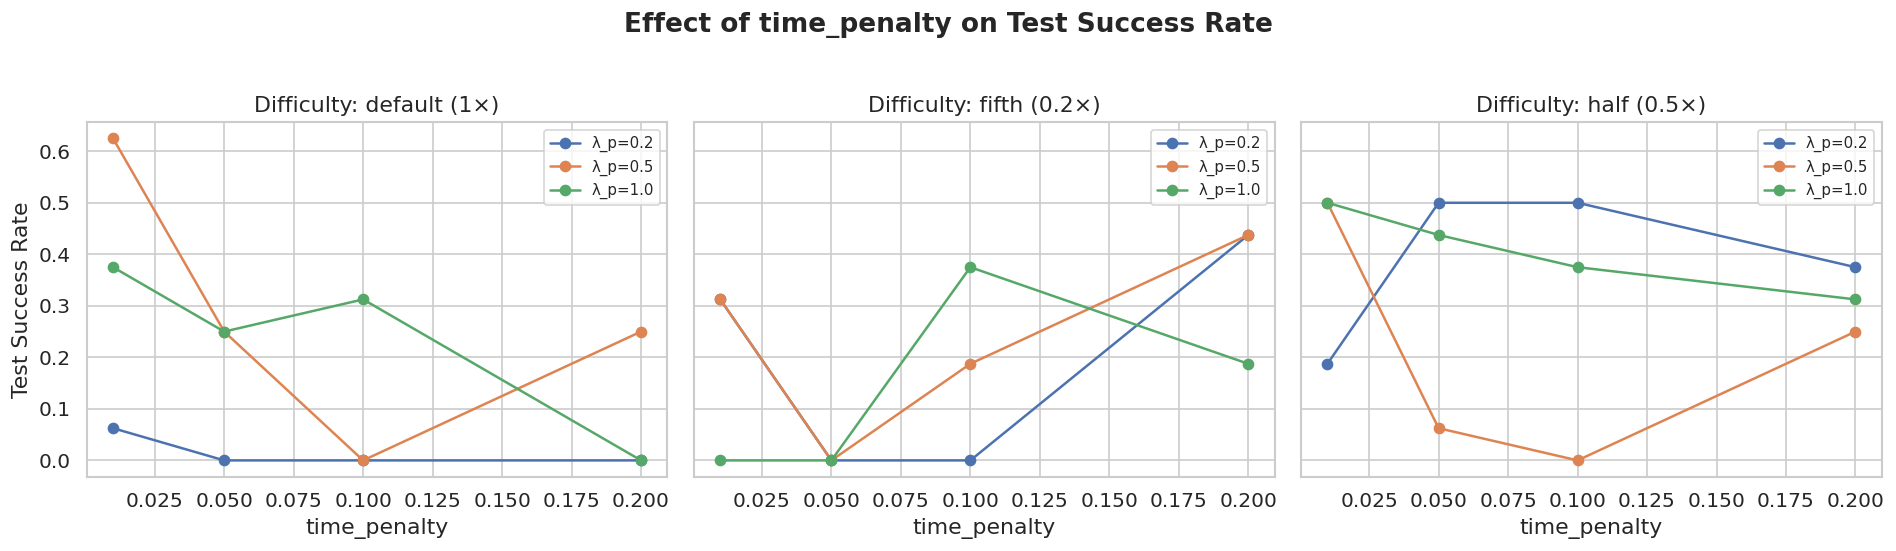

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, (diff, grp) in zip(axes, df.groupby("difficulty")):
    for lp, sub in grp.groupby("lambda_p"):
        sub_sorted = sub.sort_values("time_penalty")
        ax.plot(sub_sorted["time_penalty"], sub_sorted["test_success_rate"],
                marker="o", label=f"λ_p={lp}")
    ax.set_title(f"Difficulty: {diff}")
    ax.set_xlabel("time_penalty")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Test Success Rate")
fig.suptitle("Effect of time_penalty on Test Success Rate", fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

In [7]:
TABLE_COLS = [
    "run_id", "time_penalty", "lambda_p", "difficulty",
    "test_success_rate", "test_directness", "test_exploration", "test_risk_exposure",
]

df_table = (
    df[TABLE_COLS]
    .sort_values("test_success_rate", ascending=False)
    .reset_index(drop=True)
)

try:
    from itables import show
    show(df_table, paging=False, columnDefs=[{"className": "dt-center", "targets": "_all"}])
except ImportError:
    float_cols = df_table.select_dtypes(include="number").columns
    display(
        df_table.style
        .format({c: "{:.4f}" for c in float_cols})
        .background_gradient(subset=["test_success_rate"], cmap="RdYlGn")
    )
    print("\n(Tip: pip install itables for interactive sorting)")

Loading ITables v2.7.3 from the internet... (need help?)


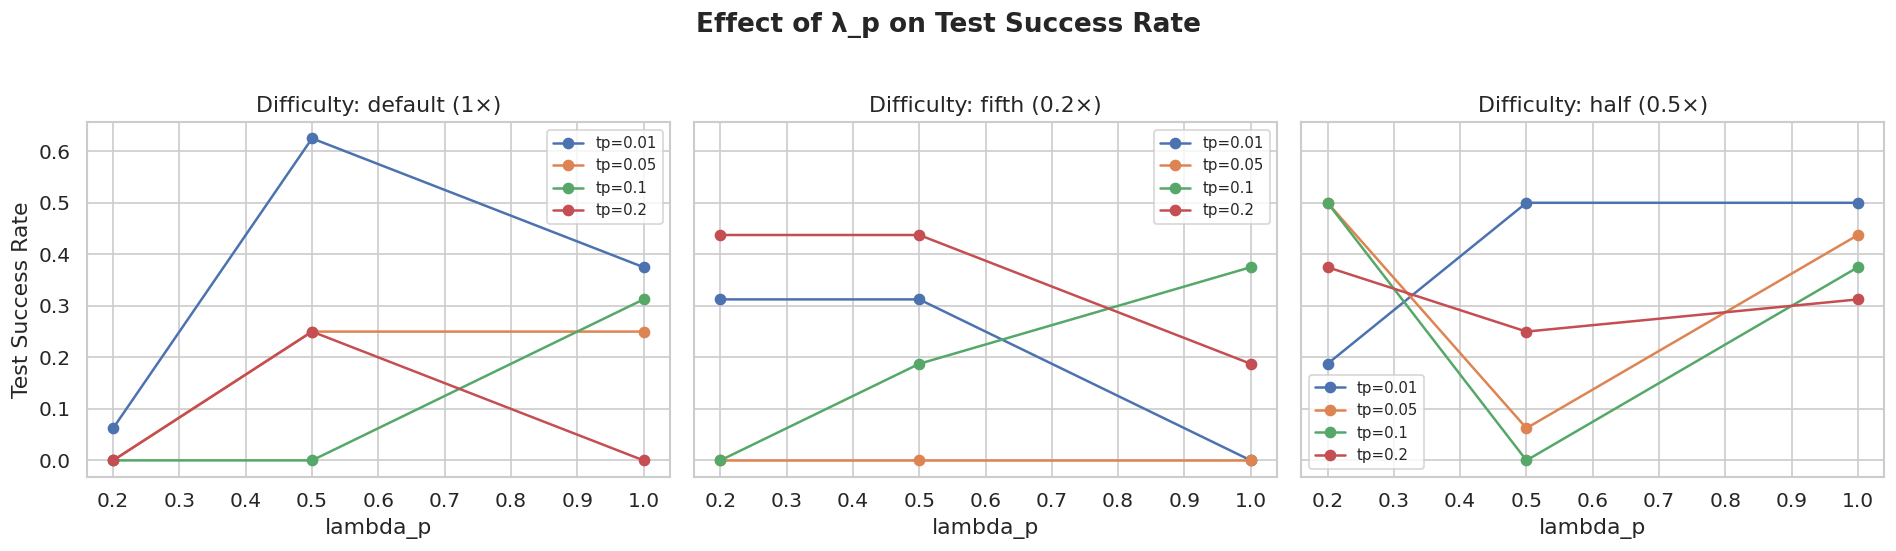

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, (diff, grp) in zip(axes, df.groupby("difficulty")):
    for tp, sub in grp.groupby("time_penalty"):
        sub_sorted = sub.sort_values("lambda_p")
        ax.plot(
            sub_sorted["lambda_p"],
            sub_sorted["test_success_rate"],
            marker="o", label=f"tp={tp}",
        )
    ax.set_title(f"Difficulty: {diff}")
    ax.set_xlabel("lambda_p")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Test Success Rate")
fig.suptitle("Effect of λ_p on Test Success Rate", fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 4c. `difficulty` vs test success rate

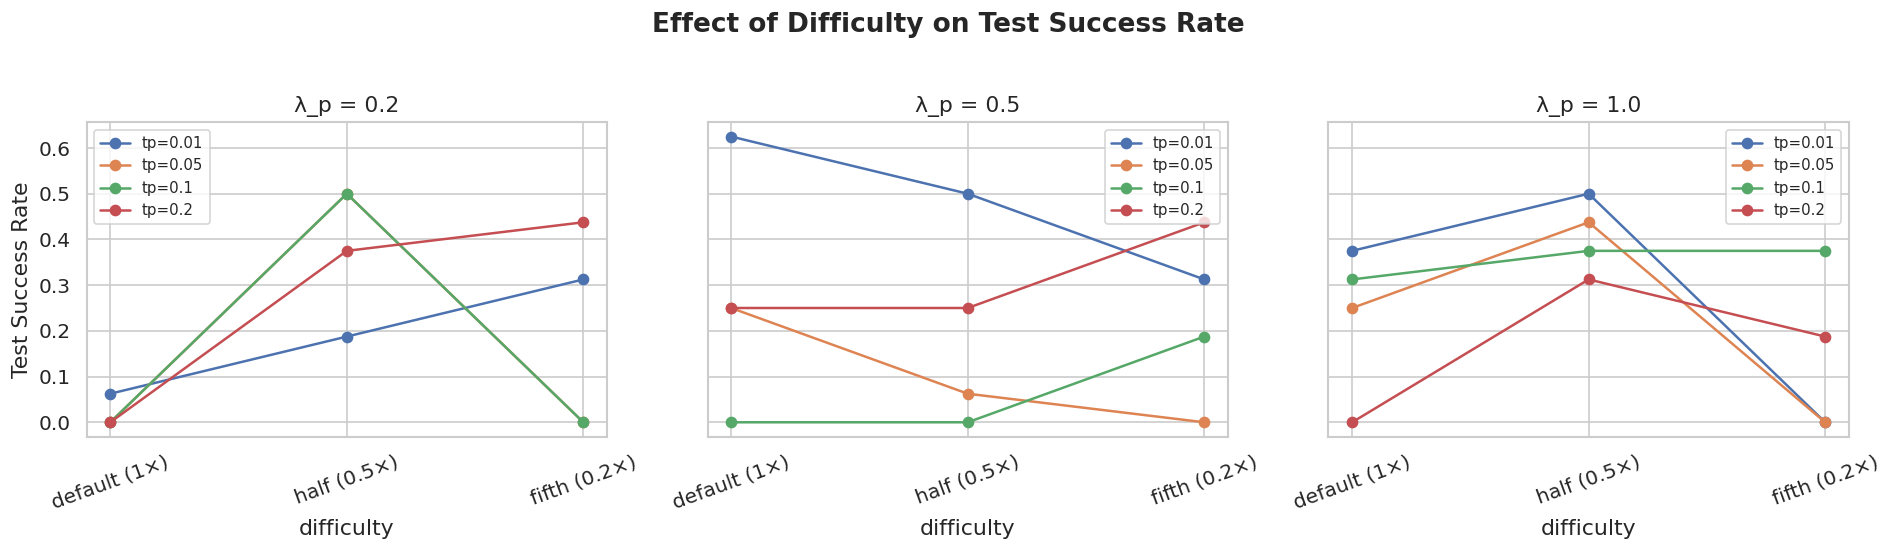

In [9]:
DIFF_ORDER = ["default (1×)", "half (0.5×)", "fifth (0.2×)"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, (lp, grp) in zip(axes, df.groupby("lambda_p")):
    for tp, sub in grp.groupby("time_penalty"):
        sub = sub.set_index("difficulty").reindex(DIFF_ORDER).reset_index()
        ax.plot(
            sub["difficulty"],
            sub["test_success_rate"],
            marker="o", label=f"tp={tp}",
        )
    ax.set_title(f"λ_p = {lp}")
    ax.set_xlabel("difficulty")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Test Success Rate")
fig.suptitle("Effect of Difficulty on Test Success Rate", fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 5. Marginal effect (averaged over other axes)

Each sweep variable averaged across the other two for a clearer aggregate trend.

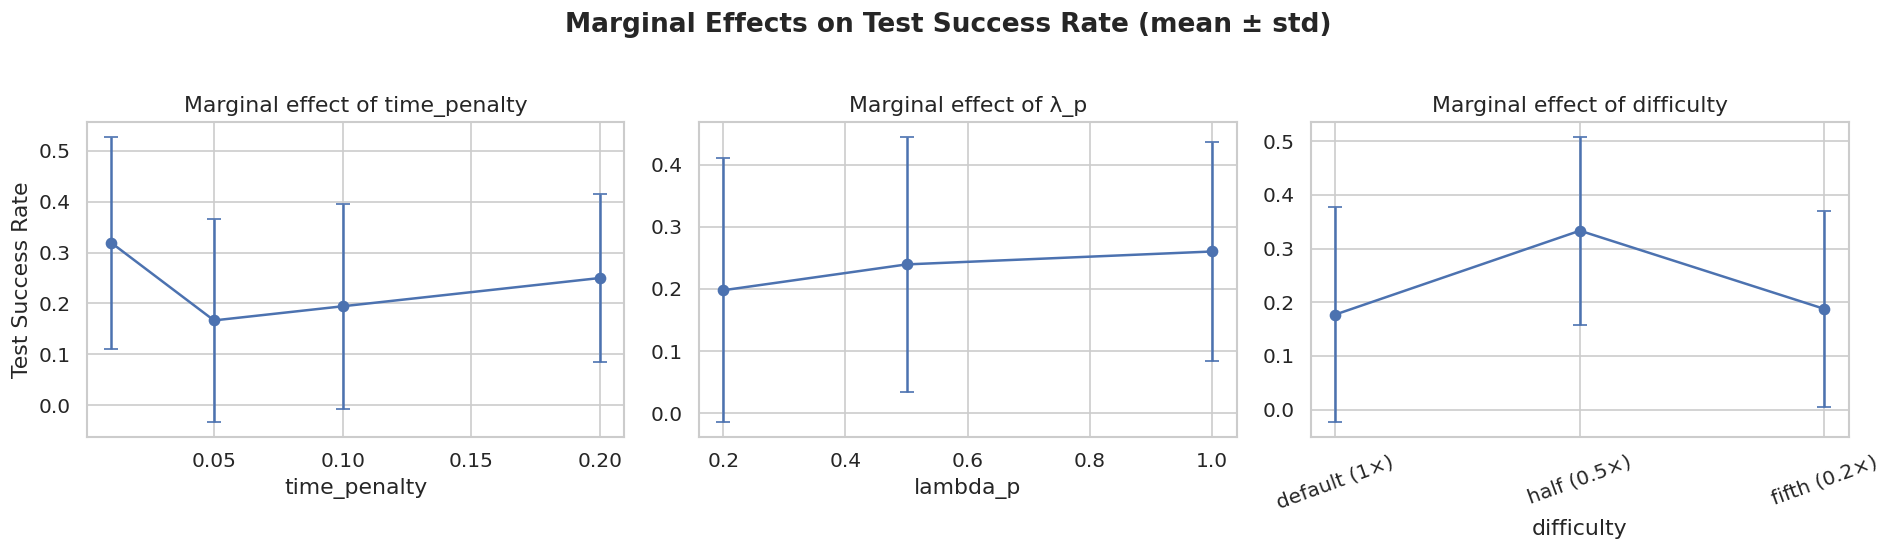

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# time_penalty
agg = df.groupby("time_penalty")["test_success_rate"].agg(["mean", "std"]).reset_index()
axes[0].errorbar(agg["time_penalty"], agg["mean"], yerr=agg["std"], marker="o", capsize=4)
axes[0].set_xlabel("time_penalty")
axes[0].set_ylabel("Test Success Rate")
axes[0].set_title("Marginal effect of time_penalty")

# lambda_p
agg = df.groupby("lambda_p")["test_success_rate"].agg(["mean", "std"]).reset_index()
axes[1].errorbar(agg["lambda_p"], agg["mean"], yerr=agg["std"], marker="o", capsize=4)
axes[1].set_xlabel("lambda_p")
axes[1].set_title("Marginal effect of λ_p")

# difficulty
agg = df.groupby("difficulty")["test_success_rate"].agg(["mean", "std"]).reindex(DIFF_ORDER).reset_index()
axes[2].errorbar(range(len(agg)), agg["mean"], yerr=agg["std"], marker="o", capsize=4)
axes[2].set_xticks(range(len(agg)))
axes[2].set_xticklabels(agg["difficulty"], rotation=20)
axes[2].set_xlabel("difficulty")
axes[2].set_title("Marginal effect of difficulty")

fig.suptitle("Marginal Effects on Test Success Rate (mean ± std)", fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 6. Correlation matrix: hyperparameters × behavioral metrics

Pearson correlation between the swept hyperparameters and behavioral metrics in both **validation** and **test** (deterministic policy).

Difficulty is encoded numerically as the terrain resource-cost multiplier: default=1.0, half=0.5, fifth=0.2.

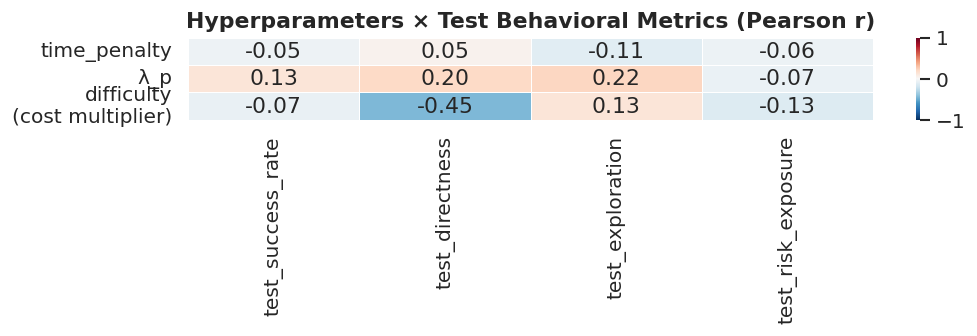

In [11]:
df_corr = df.copy()
df_corr["difficulty_num"] = df_corr["difficulty"].map(DIFFICULTY_NUMERIC)

hp_cols     = ["time_penalty", "lambda_p", "difficulty_num"]
metric_cols = ["test_success_rate", "test_directness", "test_exploration", "test_risk_exposure"]

corr_subset = df_corr[hp_cols + metric_cols].corr().loc[hp_cols, metric_cols]

fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(corr_subset, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Hyperparameters × Test Behavioral Metrics (Pearson r)", fontweight="bold")
ax.set_yticklabels(["time_penalty", "λ_p", "difficulty\n(cost multiplier)"], rotation=0)
fig.tight_layout()
plt.show()

### Full correlation matrix

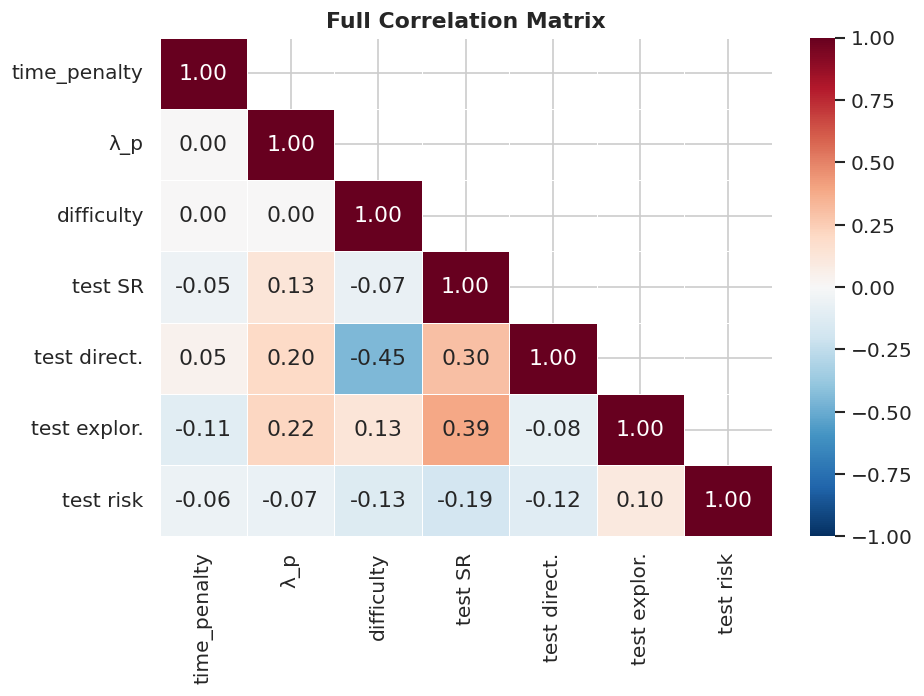

In [12]:
all_cols  = hp_cols + metric_cols
full_corr = df_corr[all_cols].corr()
labels    = ["time_penalty", "λ_p", "difficulty", "test SR", "test direct.", "test explor.", "test risk"]
mask      = np.triu(np.ones_like(full_corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(full_corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            xticklabels=labels, yticklabels=labels)
ax.set_title("Full Correlation Matrix", fontweight="bold")
fig.tight_layout()
plt.show()

## 7. Behavioral metrics by difficulty

/tmp/ipykernel_406084/2374809869.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="difficulty", y=col, order=DIFF_ORDER, ax=ax, palette="Set2")
/tmp/ipykernel_406084/2374809869.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="difficulty", y=col, order=DIFF_ORDER, ax=ax, palette="Set2")
/tmp/ipykernel_406084/2374809869.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="difficulty", y=col, order=DIFF_ORDER, ax=ax, palette="Set2")


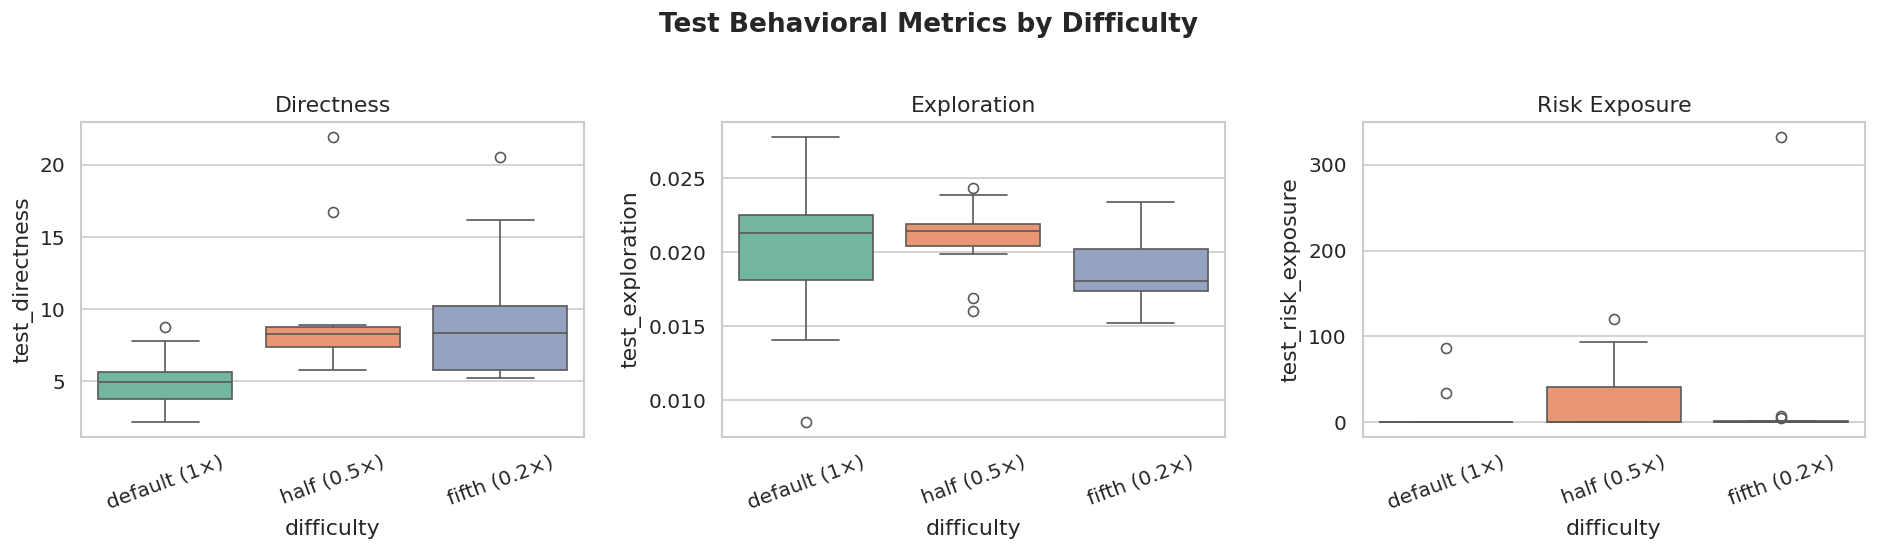

In [13]:
behavioral = ["test_directness", "test_exploration", "test_risk_exposure"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col in zip(axes, behavioral):
    sns.boxplot(data=df, x="difficulty", y=col, order=DIFF_ORDER, ax=ax, palette="Set2")
    ax.set_title(col.replace("test_", "").replace("_", " ").title())
    ax.set_xlabel("difficulty")
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Test Behavioral Metrics by Difficulty", fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()